# Analysis of FVA vs MFA Confidence intervals

## Interpretation of metrics

### 1. Consistency Score
- *the fraction of reactions where FVA prediction is consistent with MFA*
- binary (overlaps or not)
$$C = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(Range_{MFA,i} \cap Range_{FVA,i})$$

### 2. Range Precision
- *the ratio of uncertainty of flux bounds*
- if comparing $\frac{FVA}{MFA}$, this will tell the FVA is X times more uncertain
$$R_i = \frac{UB_{FVA,i} - LB_{FVA,i}}{UB_{MFA,i} - LB_{MFA,i}}$$

### 3. Normalized Euclidean Distance
- *the aggregate distance from the MFA mean flux to the *nearest feasible bound* of the FVA*
- lower is better
$$D = \sum_{i=1}^{N} \min_{v \in [LB_{FVA}, UB_{FVA}]} (v - \mu_{MFA, i})^2$$

### 4. Jaccard Index 
- *a geometric measure of how well the two uncertainty ranges align*
- higher is better.**J = 1.0:** Perfect alignment of uncertainty.
$$J_i = \frac{\text{width}(Range_{MFA,i} \cap Range_{FVA,i})}{\text{width}(Range_{MFA,i} \cup Range_{FVA,i})}$$


In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import cobra
import numpy as np

# Directories
ROOT_DIR = os.path.abspath('..')

if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
    

In [2]:
mfa_path = os.path.join(ROOT_DIR, 'data', 'experimental','crown_fluxomics_final.csv')
cobra_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20260112_7828','iML1515_GEM_cobra_fva_results.csv')
pre_tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20260112_7828','iML1515_GEM_pre_tuning_fva_results.csv')
tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20260112_7828','iML1515_GEM_fva_results.csv')

In [3]:
from kinGEMs.fluxomics_validation import create_net_FVA_dataframe

pre_tuned_net_fva_df = create_net_FVA_dataframe(pre_tuned_fva_path)
cobra_net_fva_df = create_net_FVA_dataframe(cobra_fva_path)
tuned_net_fva_df = create_net_FVA_dataframe(tuned_fva_path)

2026-01-20 10:32:53.081 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: /scratch/chinasse/kinGEMs_v2


Irreversible model FVA dataframe has 3375 rows
Net FVA dataframe has 2712 rows
Irreversible model FVA dataframe has 3375 rows
Net FVA dataframe has 2712 rows
Irreversible model FVA dataframe has 3375 rows
Net FVA dataframe has 2712 rows


In [4]:
from kinGEMs.fluxomics_validation import create_fva_comparison_dataframe

df_tuned_fva = create_fva_comparison_dataframe(
    tuned_net_fva_df,
    mfa_path,
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_cobra_fva = create_fva_comparison_dataframe(
    cobra_net_fva_df,
    mfa_path,
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_pre_tuned_fva = create_fva_comparison_dataframe(
    pre_tuned_net_fva_df,
    mfa_path,
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)


TypeError: create_fva_comparison_dataframe() missing 1 required positional argument: 'fva_columns'

In [4]:
from kinGEMs.fluxomics_validation import (calculate_consistency_score, 
                                        calculate_range_precision_ratio, 
                                        calculate_normalized_euclidean_dist, 
                                        calculate_jaccard_index)

print(f"COBRA FVA")
consistency_score = calculate_consistency_score(df_cobra_fva)
range_precision_ratio = calculate_range_precision_ratio(df_cobra_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_cobra_fva)
jaccard_index_cobra, jaccard_df_cobra, zero_overlaps_cobra = calculate_jaccard_index(df_cobra_fva)

print(f"\nPre-tuned FVA")
consistency_score = calculate_consistency_score(df_pre_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_pre_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_pre_tuned_fva)
jaccard_index_pre, jaccard_df_pre, zero_overlaps_pre = calculate_jaccard_index(df_pre_tuned_fva)


print(f"\nTuned FVA")
consistency_score = calculate_consistency_score(df_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_tuned_fva)
jaccard_index_tuned, jaccard_df_tuned, zero_overlaps_tuned = calculate_jaccard_index(df_tuned_fva)

COBRA FVA

--- Consistency Score Analysis ---
Evaluated 46 reactions
Consistent reactions: 39
Consistency Score: 0.8478

--- Range Precision Analysis ---
Evaluated 46 reactions
Median FVA width: 68.3549
Median MFA width: 0.1784
Median Precision Ratio: 570.1423

--- Euclidean Distance Analysis ---
Evaluated 46 reactions
Reactions with mean outside FVA range: 11
Sum of Squared Distances (SSD): 225.1870

--- Jaccard Index Analysis ---
Evaluated 46 reactions
Perfect overlaps (J=1.0): 0
Zero overlaps (J=0.0): 10
Mean Jaccard Index: 0.0057

Pre-tuned FVA

--- Consistency Score Analysis ---
Evaluated 46 reactions
Consistent reactions: 11
Consistency Score: 0.2391

--- Range Precision Analysis ---
Evaluated 46 reactions
Median FVA width: 0.0462
Median MFA width: 0.1784
Median Precision Ratio: 0.3185

--- Euclidean Distance Analysis ---
Evaluated 46 reactions
Reactions with mean outside FVA range: 41
Sum of Squared Distances (SSD): 647.6219

--- Jaccard Index Analysis ---
Evaluated 46 reactions

Splitting visualization into 2 plots for readability.


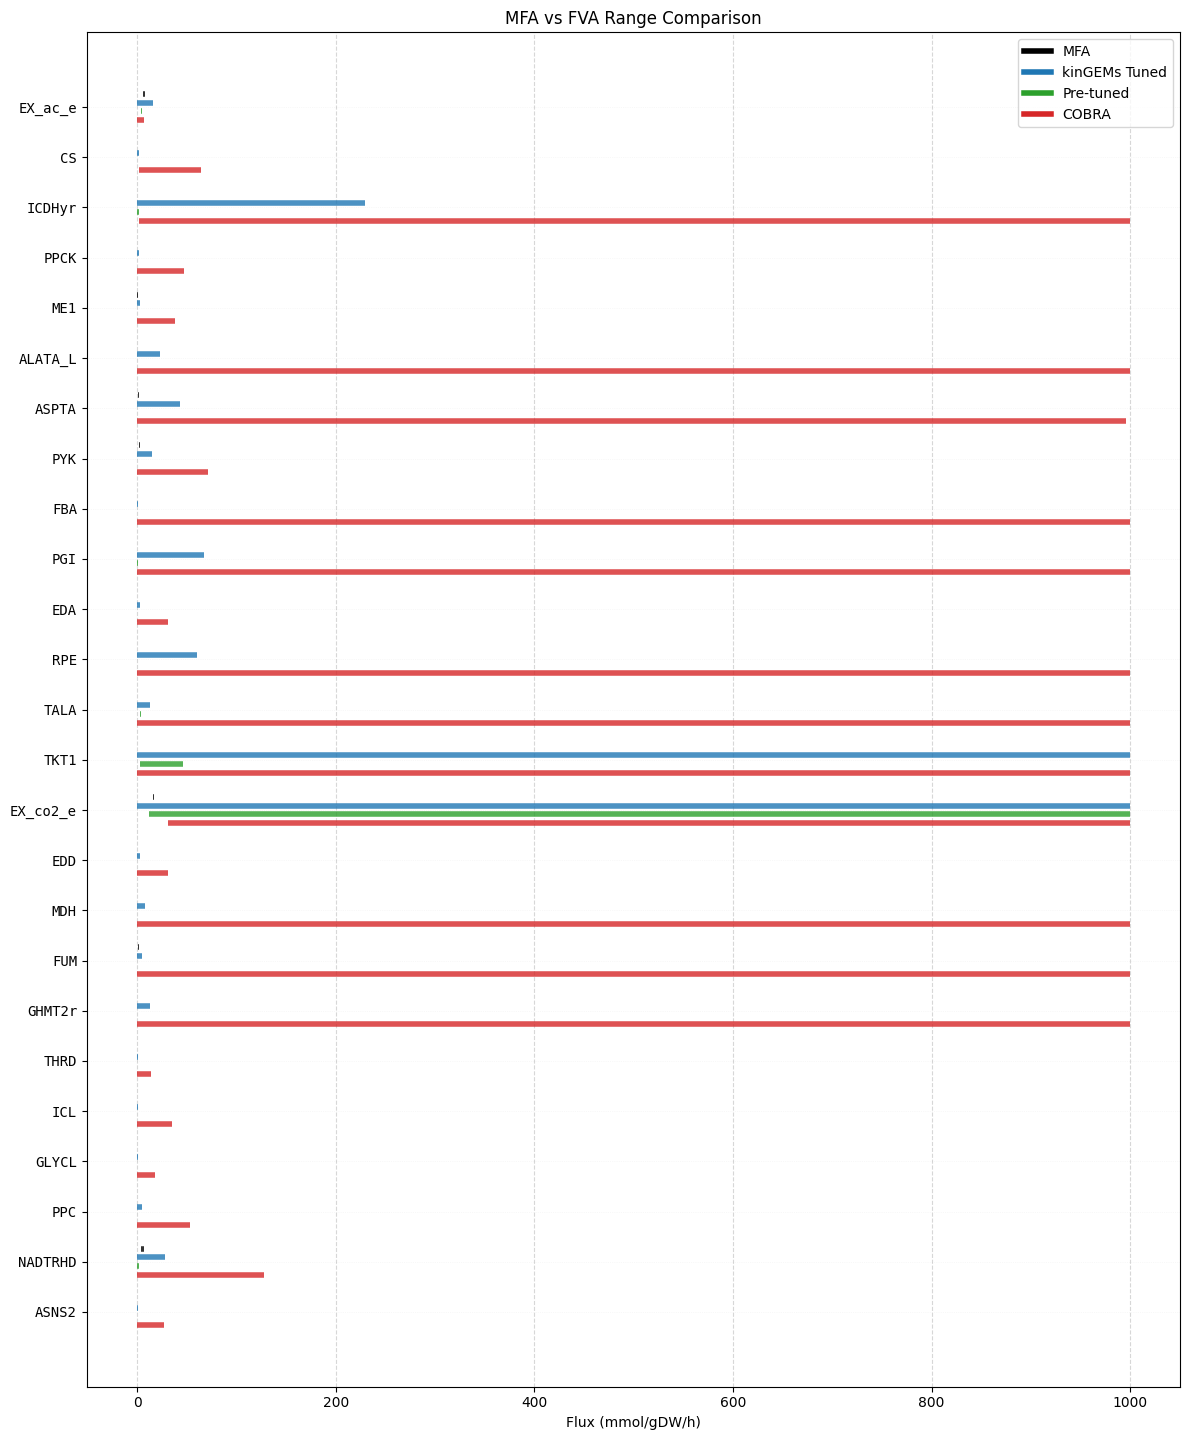

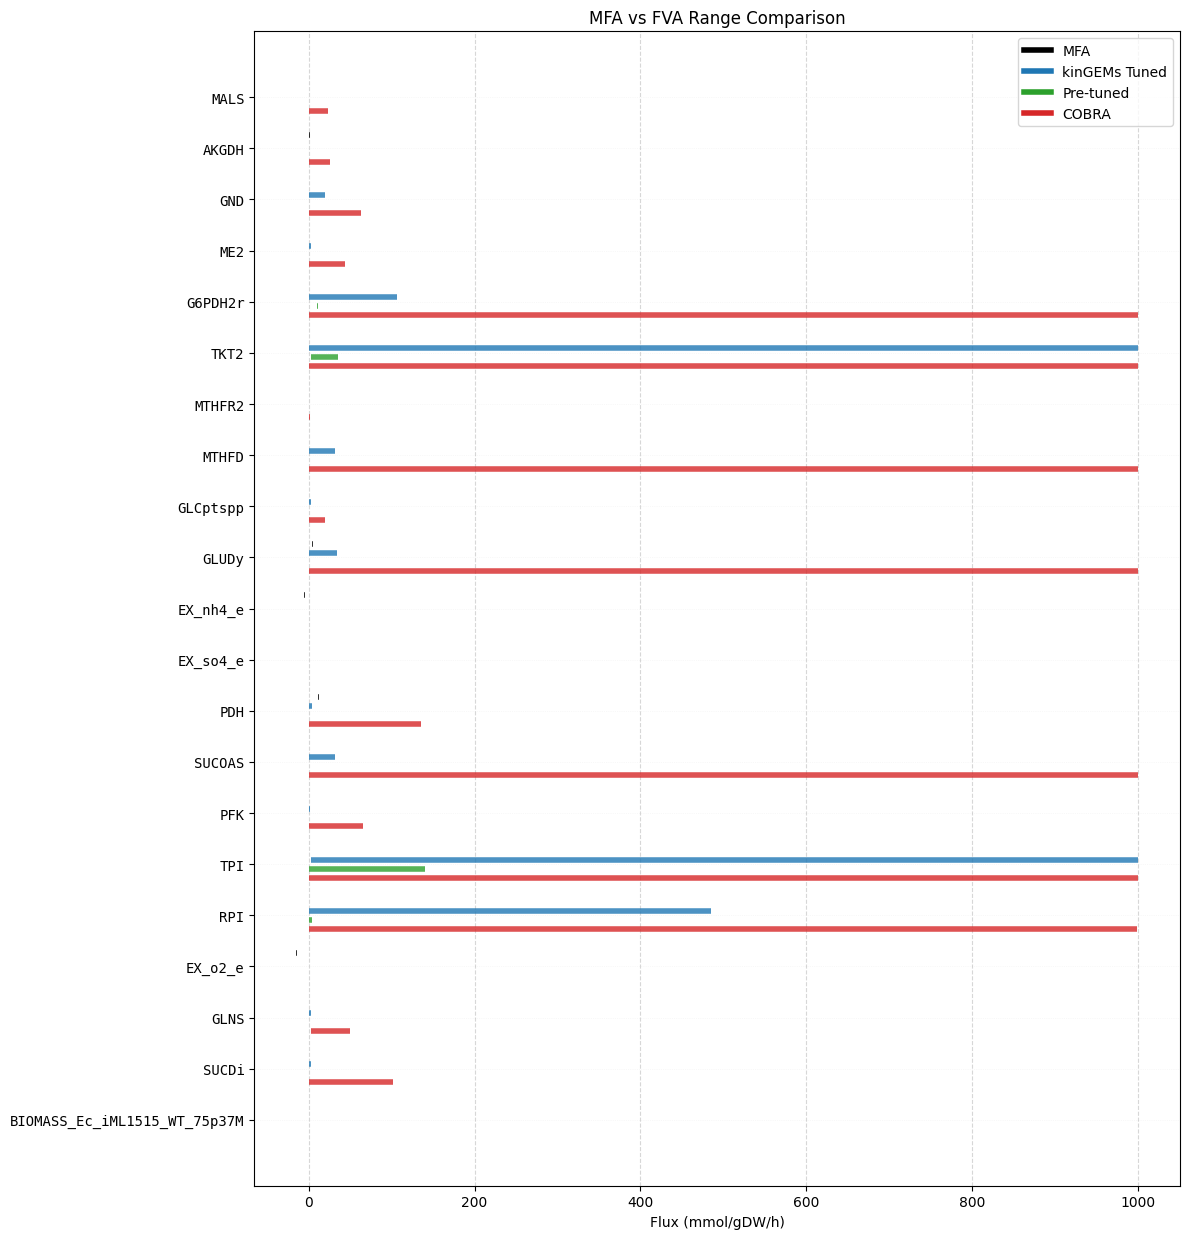

In [5]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva, 'Pre-tuned': df_pre_tuned_fva, 'COBRA': df_cobra_fva})

### TO DO
- Fluxes shouldn't be negative, pipeeline is now irreversible
- Correct mapping of MFA-FVA to include the '_reverse' cases

## Plotting Jaccard Indices

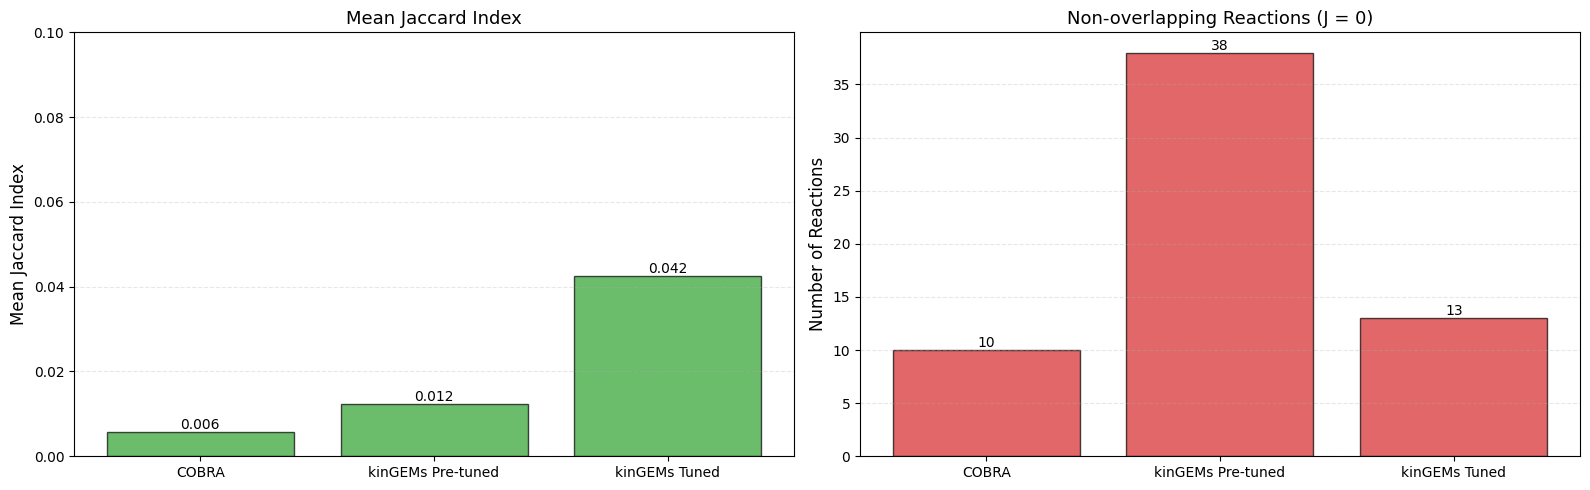

In [6]:
from kinGEMs.fluxomics_validation import plot_jaccard_index_comparison

list_jaccard_indices = [jaccard_index_cobra, jaccard_index_pre, jaccard_index_tuned]
list_zero_overlaps = [zero_overlaps_cobra, zero_overlaps_pre, zero_overlaps_tuned]
model_names = ['COBRA', 'kinGEMs Pre-tuned', 'kinGEMs Tuned']
plot_jaccard_index_comparison(list_jaccard_indices, list_zero_overlaps, model_names)

## Trimming to the rxns with the highest Jaccard Index

In [7]:
# Sort jaccard values in descending order
jaccard_sorted = jaccard_df_cobra.sort_values('jaccard', ascending=False)

# top 15 reaction IDs
top_rxn_ids = jaccard_sorted.head(15)['rxn_id'].tolist()

print("Top 15 reactions by Jaccard Index:")
print(jaccard_sorted.head(15))

# Filter dfs to top jaccard reactions
df_tuned_fva_top = df_tuned_fva[df_tuned_fva['rxn_id'].isin(top_rxn_ids)]
df_pre_tuned_fva_top = df_pre_tuned_fva[df_pre_tuned_fva['rxn_id'].isin(top_rxn_ids)]
df_cobra_fva_top = df_cobra_fva[df_cobra_fva['rxn_id'].isin(top_rxn_ids)]

Top 15 reactions by Jaccard Index:
     rxn_id   jaccard
0   EX_ac_e  0.132612
23  NADTRHD  0.019506
4       ME1  0.017581
28      ME2  0.015466
7       PYK  0.012027
26    AKGDH  0.010339
37      PDH  0.008545
22      PPC  0.006807
25     MALS  0.006071
3      PPCK  0.005143
1        CS  0.004129
20      ICL  0.003895
27      GND  0.003295
19     THRD  0.002793
15      EDD  0.002175


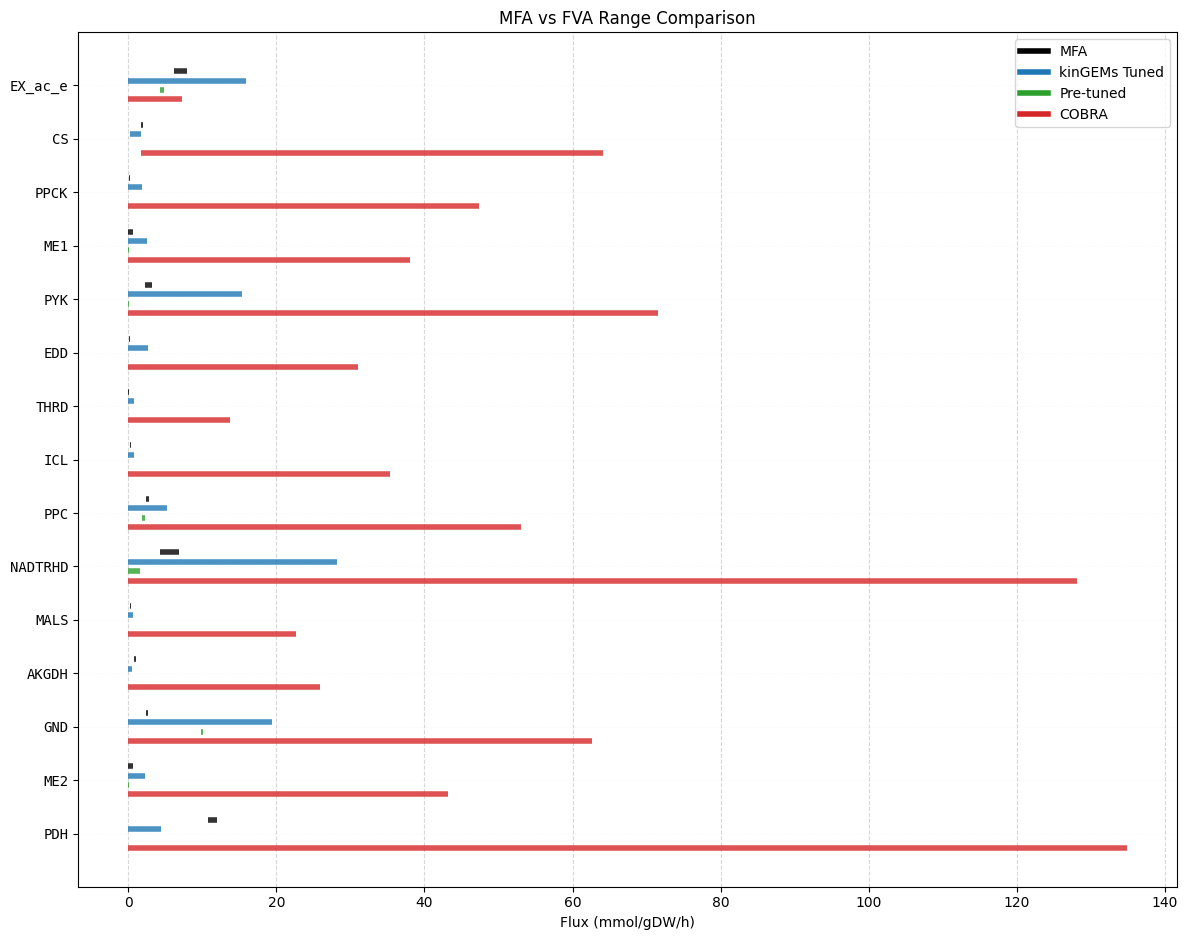

In [8]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva_top, 'Pre-tuned': df_pre_tuned_fva_top, 'COBRA': df_cobra_fva_top})

## Trimming to the rxns with improved overlap

Cases were kinGEMs Tuned (blue bars) align with MFA (black bars).

In [9]:
selected_reactions = ['CS', 'ICDHyr', 'PPC', 'PDH', 'AKGDH']
df_select_tuned = df_tuned_fva[df_tuned_fva['rxn_id'].isin(selected_reactions)]
df_select_pre = df_pre_tuned_fva[df_pre_tuned_fva['rxn_id'].isin(selected_reactions)]
df_select_cobra = df_cobra_fva[df_cobra_fva['rxn_id'].isin(selected_reactions)]

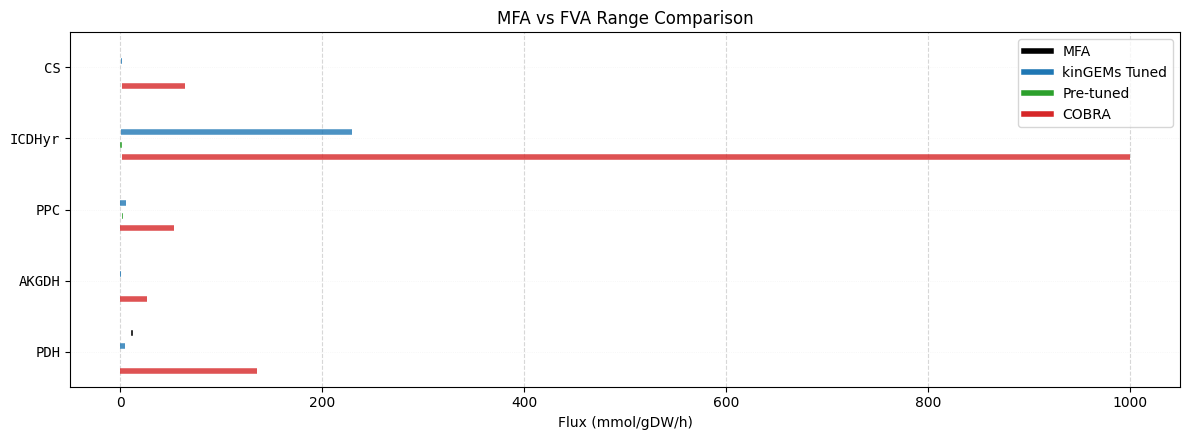

In [10]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_select_tuned, 'Pre-tuned': df_select_pre, 'COBRA': df_select_cobra})

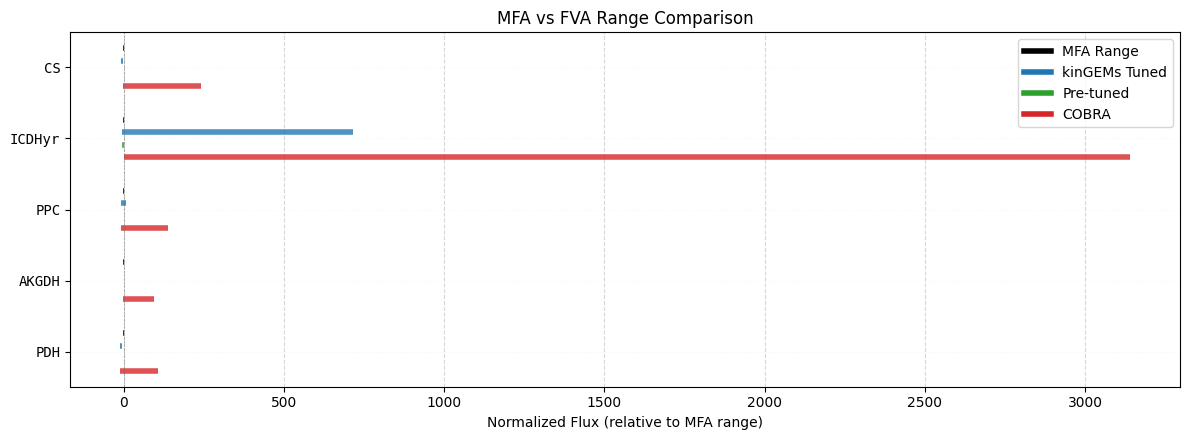

In [11]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison_normalized

plot_fva_mfa_comparison_normalized({'kinGEMs Tuned': df_select_tuned, 'Pre-tuned': df_select_pre, 'COBRA': df_select_cobra})

## COBRApy vs kinGEMs tuned

In [12]:
from kinGEMs.fluxomics_validation import create_fva_comparison_dataframe

df_cobra_kingems_fva = create_fva_comparison_dataframe(
    tuned_fva_path,
    cobra_fva_path,
    fva_columns=['Reactions','Min Solutions','Max Solutions'],
    mfa_columns=['Reactions','Min Solutions','Max Solutions']
)

Loaded 3375 FVA flux results
Loaded 3375 MFA flux measurements
Merged dataframe has 3375 rows
Matched reactions: 3375
Unmatched reactions: 0



In [13]:
from kinGEMs.fluxomics_validation import (calculate_consistency_score, 
                                        calculate_range_precision_ratio, 
                                        calculate_normalized_euclidean_dist, 
                                        calculate_jaccard_index)

consistency_score = calculate_consistency_score(df_cobra_kingems_fva)
range_precision_ratio = calculate_range_precision_ratio(df_cobra_kingems_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_cobra_kingems_fva)
jaccard_index = calculate_jaccard_index(df_cobra_kingems_fva)


--- Consistency Score Analysis ---
Evaluated 3375 reactions
Consistent reactions: 3265
Consistency Score: 0.9674

--- Range Precision Analysis ---
Evaluated 3375 reactions
Median FVA width: 0.9055
Median MFA width: 23.6785
Median Precision Ratio: 0.0191

--- Euclidean Distance Analysis ---
Evaluated 3375 reactions
Reactions with mean outside FVA range: 2489
Sum of Squared Distances (SSD): 267817068.9844

--- Jaccard Index Analysis ---
Evaluated 3375 reactions
Perfect overlaps (J=1.0): 156
Zero overlaps (J=0.0): 807
Mean Jaccard Index: 0.0871
